In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lobster import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [3]:
message_csv  = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_message_5.csv"
orderbook_csv = "/Users/rebeccalaik/Desktop/imperial/microstructure/LOBSTER_SampleFile_INTC_2012-06-21_5/INTC_2012-06-21_34200000_57600000_orderbook_5.csv"


msg, ob, qr, df = load_lobster_data(
    message_csv,
    orderbook_csv,
    levels=10,
    K=5
)

/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/internals/managers.py:1753: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr
/Users/rebeccalaik/miniforge3/envs/ml/lib/python3.12/site-packages/pandas/core/i

In [4]:
aes = compute_aes_by_level(df, K=5)
df_norm = normalize_by_aes(df, aes, K=5) 

In [5]:
df_norm

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,72,267150.0,267200.0,183,...,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,38,267150.0,267200.0,183,...,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,2,267150.0,267200.0,183,...,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,1,267150.0,267200.0,183,...,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98,1157


In [6]:
#idée : shift event car indice k correspond à l'event d'avant dans l'OB

def shift_orderbook_before_event(df, K):

    df_shift = df.copy()

    for i in range(1, K+1):

        df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
        df_shift[f"Q_-{i}"] = df_shift[f"Q_-{i}"].shift(1)

    return df_shift


df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)

In [7]:
# Apply log(1+q) transform to queue sizes (c la transo du papier)
def log_transform_queues(df, K):

    df = df.copy()

    for i in range(1, K+1):
        df[f"Q_{i}"] = np.log1p(df[f"Q_{i}"])
        df[f"Q_-{i}"] = np.log1p(df[f"Q_-{i}"])

    return df


df_qr = log_transform_queues(df_qr, K=5)

In [8]:
# Build additional MDQR state variables:
# - spread at the best prices
# - trade imbalance from bid and ask queue volumes
# - hour of the day
#- TI_rho(t_k) uses traded volumes on bid/ask sides over rolling time windows.

def add_mdqr_features(df, K, windows=(20.0, 60.0, 300.0, 900.0)):
   
    out = df.copy()

    # spread in ticks / price units
    out["spread"] = out["P_1"] - out["P_-1"]

    # traded volume by side:
    out["trade_bid_vol"] = np.where(out["type"] == "M", np.where(out["lvl"] > 0, out["size"], 0.0), 0.0)
    out["trade_ask_vol"] = np.where(out["type"] == "M", np.where(out["lvl"] < 0, out["size"], 0.0), 0.0)

    # rolling TI over time windows
    tmp = out[["time", "trade_bid_vol", "trade_ask_vol"]].copy()
    tmp["time_dt"] = pd.to_datetime(tmp["time"], unit="s")

    tmp = tmp.set_index("time_dt")

    for w in windows:
        bid_roll = tmp["trade_bid_vol"].rolling(f"{int(w)}s").sum()
        ask_roll = tmp["trade_ask_vol"].rolling(f"{int(w)}s").sum()

        ti = (bid_roll - ask_roll) / (bid_roll + ask_roll + 1e-8)

        if w == 20.0:
            col = "TI_20s"
        elif w == 60.0:
            col = "TI_1min"
        elif w == 300.0:
            col = "TI_5min"
        elif w == 900.0:
            col = "TI_15min"
        else:
            col = f"TI_{int(w)}s"

        out[col] = ti.values

    out[["TI_20s", "TI_1min", "TI_5min", "TI_15min"]] = (
        out[["TI_20s", "TI_1min", "TI_5min", "TI_15min"]].fillna(0.0)
    )

    out["hour"] = (out["time"] // 3600).astype(int)

    return out


df_qr = add_mdqr_features(df_qr, K=5)

In [9]:
#keep only the variable needed for the event by event MDQR sequence


def build_mdqr_sequence(df, K):

    q_cols = []

    for i in range(1, K+1):
        q_cols.append(f"Q_-{i}")

    for i in range(1, K+1):
        q_cols.append(f"Q_{i}")

    seq = df[
        ["type",
         "lvl",
         "size",
         "dtk",
         "spread",
         "TI_20s",
         "TI_1min",
         "TI_5min",
         "TI_15min",
         "hour"]
        + q_cols
    ].copy()

    seq = seq.reset_index(drop=True)

    return seq


mdqr_seq = build_mdqr_sequence(df_qr, K=5)

In [10]:
# considérer que x_k = ce qu'il y a dans table 3 
#pour le reseau intensité : lui donner xk uniquement
#pr le reseau de size lui donner xk et aussi previous event type previous event level et previous event time (au global cad tk)


def add_previous_event_features(seq):

    df = seq.copy()

    df["omega_prev"] = df["type"].shift(1)
    df["level_prev"] = df["lvl"].shift(1)
    df["size_prev"] = df["size"].shift(1)

    return df


mdqr_seq = add_previous_event_features(mdqr_seq)

In [11]:
mdqr_seq

,type,lvl,size,dtk,spread,TI_20s,TI_1min,TI_5min,TI_15min,hour,...,Q_-4,Q_-5,Q_1,Q_2,Q_3,Q_4,Q_5,omega_prev,level_prev,size_prev
0,L,4,1,0.000221,100.0,0.000000,0.000000,0.000000,0.000000,9,...,1.098612,0.693147,0.693147,1.386294,0.693147,0.0,0.693147,None,NaN,<NA>
1,C,-2,1,0.042402,100.0,0.000000,0.000000,0.000000,0.000000,9,...,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,L,4.0,1
2,C,-1,1,0.000020,100.0,0.000000,0.000000,0.000000,0.000000,9,...,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,C,-2.0,1
3,L,-2,1,0.000106,100.0,0.000000,0.000000,0.000000,0.000000,9,...,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,C,-1.0,1
4,L,-3,2,0.000022,100.0,0.000000,0.000000,0.000000,0.000000,9,...,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,L,-2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580345,C,1,72,0.011408,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,4.60517,4.59512,5.541264,5.966147,5.501258,4.836282,4.634729,L,1.0,3
580346,L,-2,38,0.000191,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,4.60517,4.59512,5.214936,5.966147,5.501258,4.836282,4.634729,C,1.0,72
580347,C,3,2,0.009473,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,4.60517,4.59512,5.214936,5.966147,5.501258,4.836282,4.634729,L,-2.0,38
580348,L,1,1,0.069536,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,4.60517,4.59512,5.214936,5.966147,5.493061,4.836282,4.634729,C,3.0,2


In [ ]:
#corriger pr ei_tk pr les niveaux ou aucun event n'a occur 


def add_mdqr_categorical_features(df, K):
    """
    Categorical features from the paper:
    - omega: current event type code {L:0, C:1, M:2}
    - hour_idx: categorical hour index
    - e_i: last event type at each level i before current event

    We also keep previous-event features for the size model:
    - omega_prev
    - level_prev
    - size_prev
    """
    out = df.copy()

    event_map = {"L": 0, "C": 1, "M": 2}
    pad_code = 3 

    out["omega"] = out["type"].map(event_map).astype(int)
    out["omega_prev"] = out["omega_prev"].map(event_map)

    # remove first row because previous-event features are missing there
    out = out[out["omega_prev"].notna()].copy()
    out["omega_prev"] = out["omega_prev"].astype(int)
    out["level_prev"] = out["level_prev"].astype(int)
    out["size_prev"] = out["size_prev"].astype(float)

    unique_hours = sorted(out["hour"].dropna().unique().tolist())
    hour_to_idx = {h: i for i, h in enumerate(unique_hours)}
    out["hour_idx"] = out["hour"].map(hour_to_idx).astype(int)

    levels = list(range(-K, 0)) + list(range(1, K + 1))

    for lvl in levels:
        col = f"e_{lvl}"
        cur_lvl_event = np.where(out["lvl"] == lvl, out["omega"], np.nan)
        last_lvl_event = pd.Series(cur_lvl_event, index=out.index).ffill().shift(1)
        out[col] = last_lvl_event.fillna(pad_code).astype(int)

    out = out.reset_index(drop=True)
    return out, hour_to_idx

In [13]:
mdqr_seq, hour_to_idx = add_mdqr_categorical_features(mdqr_seq, K=5)

In [14]:
mdqr_seq

,type,lvl,size,dtk,spread,TI_20s,TI_1min,TI_5min,TI_15min,hour,...,e_-5,e_-4,e_-3,e_-2,e_-1,e_1,e_2,e_3,e_4,e_5
0,C,-2,1,0.042402,100.0,0.000000,0.000000,0.000000,0.000000,9,...,3,3,3,3,3,3,3,3,3,3
1,C,-1,1,0.000020,100.0,0.000000,0.000000,0.000000,0.000000,9,...,3,3,3,1,3,3,3,3,3,3
2,L,-2,1,0.000106,100.0,0.000000,0.000000,0.000000,0.000000,9,...,3,3,3,1,1,3,3,3,3,3
3,L,-3,2,0.000022,100.0,0.000000,0.000000,0.000000,0.000000,9,...,3,3,3,0,1,3,3,3,3,3
4,L,-4,2,0.000068,100.0,0.000000,0.000000,0.000000,0.000000,9,...,3,3,0,0,1,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580344,C,1,72,0.011408,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,1,1,1,1,1,0,1,1,1,1
580345,L,-2,38,0.000191,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,1,1,1,1,1,1,1,1,1,1
580346,C,3,2,0.009473,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,1,1,1,0,1,1,1,1,1,1
580347,L,1,1,0.069536,100.0,0.347979,0.262462,0.067367,-0.060276,15,...,1,1,1,0,1,1,1,1,1,1


In [15]:
# Split the state vector into:
# - numerical features
# - level-wise categorical features e_i(t_k)
# - categorical hour feature

def build_mdqr_state_components(df, K):
    q_cols = [f"Q_-{i}" for i in range(1, K+1)] + [f"Q_{i}" for i in range(1, K+1)]
    e_cols = [f"e_{i}" for i in list(range(-K, 0)) + list(range(1, K+1))]

    # x_k from Table 3
    X_num = df[
        q_cols + ["spread", "TI_20s", "TI_1min", "TI_5min", "TI_15min"]
    ].copy()

    X_cat_levels = df[e_cols].copy()
    X_cat_hour = df["hour_idx"].copy()

    # previous-event features used only for SizeNet
    X_prev_size = df[["omega_prev", "level_prev", "size_prev", "dtk"]].copy()

    return X_num, X_cat_levels, X_cat_hour, X_prev_size


X_num, X_cat_levels, X_cat_hour, X_prev_size = build_mdqr_state_components(mdqr_seq, K=5)

In [16]:
X_num 

,Q_-1,Q_-2,Q_-3,Q_-4,Q_-5,Q_1,Q_2,Q_3,Q_4,Q_5,spread,TI_20s,TI_1min,TI_5min,TI_15min
0,0.693147,0.693147,0.693147,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,100.0,0.000000,0.000000,0.000000,0.000000
1,0.693147,0.0,0.693147,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,100.0,0.000000,0.000000,0.000000,0.000000
2,0.693147,0.0,0.693147,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,100.0,0.000000,0.000000,0.000000,0.000000
3,0.693147,0.693147,0.693147,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,100.0,0.000000,0.000000,0.000000,0.000000
4,0.693147,0.693147,1.098612,1.098612,0.693147,0.693147,1.386294,0.693147,0.693147,0.693147,100.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580344,2.772589,4.276666,4.174387,4.60517,4.59512,5.541264,5.966147,5.501258,4.836282,4.634729,100.0,0.347979,0.262462,0.067367,-0.060276
580345,2.772589,4.276666,4.174387,4.60517,4.59512,5.214936,5.966147,5.501258,4.836282,4.634729,100.0,0.347979,0.262462,0.067367,-0.060276
580346,2.772589,4.70048,4.174387,4.60517,4.59512,5.214936,5.966147,5.501258,4.836282,4.634729,100.0,0.347979,0.262462,0.067367,-0.060276
580347,2.772589,4.70048,4.174387,4.60517,4.59512,5.214936,5.966147,5.493061,4.836282,4.634729,100.0,0.347979,0.262462,0.067367,-0.060276


In [330]:
# Encode each (event type, price level) pair as one class in {0,...,3*2K-1}.
# For K=5, this gives 30 event-level classes.

def encode_event_level(event, level, K=5):

    level = int(level)

    side_offset = 0 if level < 0 else K

    level_index = abs(level) - 1

    return event * (2*K) + side_offset + level_index

In [331]:
# Build the target y_event_level corresponding to the observed class
# (event type, level) for each row in the MDQR sequence.

def build_mdqr_targets(df, K=5):

    y_event_level = []

    for e,l in zip(df["omega"], df["lvl"]):
        y_event_level.append(encode_event_level(e,l,K))

    y_event_level = np.array(y_event_level)

    return y_event_level


y_event_level = build_mdqr_targets(mdqr_seq)

In [332]:
# Discretize order sizes into quantile-based bins.
# This transforms the size model into a classification problem.

def build_size_bins(size_series, n_bins=200):

    bins = pd.qcut(size_series, q=n_bins, duplicates="drop")

    labels = bins.cat.codes

    return labels, bins


size_classes, size_bins = build_size_bins(mdqr_seq["size"])

mdqr_seq["size_class"] = size_classes

In [333]:
class IntensityNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        emb_dim_level=2,
        emb_dim_hour=2,
        output_dim=30
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)   
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = num_numeric_features + num_level_cats * emb_dim_level + emb_dim_hour

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, output_dim),
            nn.ReLU()
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        x = torch.cat([x_num, lvl_emb, hour_emb], dim=1)
        return self.net(x)

In [334]:
class SizeNet(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        num_level_cats,
        num_hour_classes,
        num_prev_features,
        emb_dim_level=2,
        emb_dim_hour=2,
        num_classes=200
    ):
        super().__init__()

        self.level_event_emb = nn.Embedding(4, emb_dim_level)
        self.hour_emb = nn.Embedding(num_hour_classes, emb_dim_hour)

        input_dim = (
            num_numeric_features
            + num_level_cats * emb_dim_level
            + emb_dim_hour
            + 2                      # omega_cur, lvl_cur
            + num_prev_features      # omega_prev, level_prev, size_prev, dtk
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_num, x_cat_levels, x_cat_hour, omega_cur, lvl_cur, x_prev_size):
        lvl_emb = self.level_event_emb(x_cat_levels).reshape(x_cat_levels.size(0), -1)
        hour_emb = self.hour_emb(x_cat_hour)
        extra_cur = torch.stack([omega_cur.float(), lvl_cur.float()], dim=1)

        x = torch.cat([x_num, lvl_emb, hour_emb, extra_cur, x_prev_size], dim=1)
        return self.net(x)

In [335]:
def intensity_loss(lam,y,dt):

    lam_sum = lam.sum(dim=1)

    lam_event = lam[torch.arange(len(y)),y]

    loss = -(torch.log(lam_event+1e-8)-lam_sum*dt)

    return loss.mean()


size_loss = nn.CrossEntropyLoss()

In [336]:
class MDQRDataset(Dataset):

    def __init__(self, X_num, X_cat_levels, X_cat_hour, X_prev_size, df, K=5):

        X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)
        X_prev_size_clean = X_prev_size.apply(pd.to_numeric, errors="coerce").fillna(0.0)

        self.x_num = torch.tensor(
            X_num_clean.values.astype(np.float32),
            dtype=torch.float32
        )

        self.x_cat_levels = torch.tensor(
            X_cat_levels_clean.values.astype(np.int64),
            dtype=torch.long
        )

        self.x_cat_hour = torch.tensor(
            X_cat_hour.values.astype(np.int64),
            dtype=torch.long
        )

        self.x_prev_size = torch.tensor(
            X_prev_size_clean.values.astype(np.float32),
            dtype=torch.float32
        )

        self.dt = torch.tensor(
            df["dtk"].astype(float).values,
            dtype=torch.float32
        )

        self.y_event_level = torch.tensor(
            build_mdqr_targets(df, K=K),
            dtype=torch.long
        )

        self.y_size = torch.tensor(
            df["size_class"].astype(int).values,
            dtype=torch.long
        )

        self.omega_cur = torch.tensor(
            df["omega"].astype(int).values,
            dtype=torch.long
        )

        self.lvl_cur = torch.tensor(
            df["lvl"].astype(int).values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        return (
            self.x_num[idx],
            self.x_cat_levels[idx],
            self.x_cat_hour[idx],
            self.x_prev_size[idx],
            self.y_event_level[idx],
            self.y_size[idx],
            self.dt[idx],
            self.omega_cur[idx],
            self.lvl_cur[idx]
        )

In [337]:
full_dataset = MDQRDataset(X_num, X_cat_levels, X_cat_hour, X_prev_size, mdqr_seq, K=5)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024,
    shuffle=False
)

In [338]:
num_numeric_features = X_num.shape[1]
num_level_cats = X_cat_levels.shape[1]
num_prev_features = X_prev_size.shape[1]
num_hour_classes = mdqr_seq["hour_idx"].nunique()

model_intensity = IntensityNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    emb_dim_level=2,
    emb_dim_hour=2,
    output_dim=30
)

model_size = SizeNet(
    num_numeric_features=num_numeric_features,
    num_level_cats=num_level_cats,
    num_hour_classes=num_hour_classes,
    num_prev_features=num_prev_features,
    emb_dim_level=2,
    emb_dim_hour=2,
    num_classes=200
)

In [339]:
#training of the two MDQR components
# The total loss is:
# - Poisson negative log-likelihood for event/time
# - cross-entropy for order size classification
train_loss_history = []
val_loss_history = []

opt = optim.Adam(
    list(model_intensity.parameters()) +
    list(model_size.parameters()),
    lr=1e-4
)

best_val_loss = np.inf
patience = 10
epochs_no_improve = 0
max_epochs = 100

best_intensity_state = None
best_size_state = None

for epoch in range(max_epochs):

    model_intensity.train()
    model_size.train()

    train_total = 0.0

    for x_num_b, x_cat_levels_b, x_cat_hour_b, x_prev_size_b, y_ev, y_sz, dt_b, omega_cur_b, lvl_cur_b in train_loader:

        lam = model_intensity(x_num_b, x_cat_levels_b, x_cat_hour_b)
        loss_int = intensity_loss(lam, y_ev, dt_b)

        size_logits = model_size(
            x_num_b,
            x_cat_levels_b,
            x_cat_hour_b,
            omega_cur_b,
            lvl_cur_b,
            x_prev_size_b
        )
        loss_size_val = size_loss(size_logits, y_sz)

        loss = loss_int + loss_size_val

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_total += loss.item()

    train_avg = train_total / len(train_loader)
    train_loss_history.append(train_avg)

    model_intensity.eval()
    model_size.eval()

    val_total = 0.0

    with torch.no_grad():
        for x_num_b, x_cat_levels_b, x_cat_hour_b, x_prev_size_b, y_ev, y_sz, dt_b, omega_cur_b, lvl_cur_b in val_loader:

            lam = model_intensity(x_num_b, x_cat_levels_b, x_cat_hour_b)
            loss_int = intensity_loss(lam, y_ev, dt_b)

            size_logits = model_size(
                x_num_b,
                x_cat_levels_b,
                x_cat_hour_b,
                omega_cur_b,
                lvl_cur_b,
                x_prev_size_b
            )
            loss_size_val = size_loss(size_logits, y_sz)

            loss = loss_int + loss_size_val
            val_total += loss.item()

    val_avg = val_total / len(val_loader)
    val_loss_history.append(val_avg)

    print(f"epoch={epoch} train={train_avg:.4f} val={val_avg:.4f}")

    if val_avg < best_val_loss:
        best_val_loss = val_avg
        epochs_no_improve = 0
        best_intensity_state = {k: v.cpu().clone() for k, v in model_intensity.state_dict().items()}
        best_size_state = {k: v.cpu().clone() for k, v in model_size.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_intensity_state is not None:
    model_intensity.load_state_dict(best_intensity_state)

if best_size_state is not None:
    model_size.load_state_dict(best_size_state)

epoch=0 train=3.7529 val=2.4372
epoch=1 train=2.3160 val=2.2255
epoch=2 train=2.2111 val=2.1705
epoch=3 train=2.1725 val=2.1387
epoch=4 train=2.1377 val=2.1004
epoch=5 train=2.0963 val=2.0485
epoch=6 train=2.0286 val=1.9669
epoch=7 train=1.9552 val=1.9079
epoch=8 train=1.9080 val=1.9593
epoch=9 train=1.3736 val=1.2641
epoch=10 train=1.2626 val=1.2278
epoch=11 train=1.2207 val=1.1941
epoch=12 train=1.1898 val=1.1644
epoch=13 train=1.1606 val=1.1362
epoch=14 train=1.1331 val=1.1091
epoch=15 train=1.1072 val=1.0848
epoch=16 train=1.0884 val=1.0694
epoch=17 train=1.0618 val=1.0418
epoch=18 train=1.0405 val=1.0213
epoch=19 train=1.0275 val=1.0043
epoch=20 train=1.0105 val=0.9923
epoch=21 train=0.9912 val=0.9745
epoch=22 train=0.9884 val=0.9740
epoch=23 train=0.9650 val=0.9519
epoch=24 train=0.9526 val=0.9408
epoch=25 train=0.9431 val=0.9302
epoch=26 train=0.9317 val=0.9194
epoch=27 train=0.9218 val=0.9331
epoch=28 train=0.9124 val=0.8999
epoch=29 train=0.9210 val=0.9020
epoch=30 train=0.896

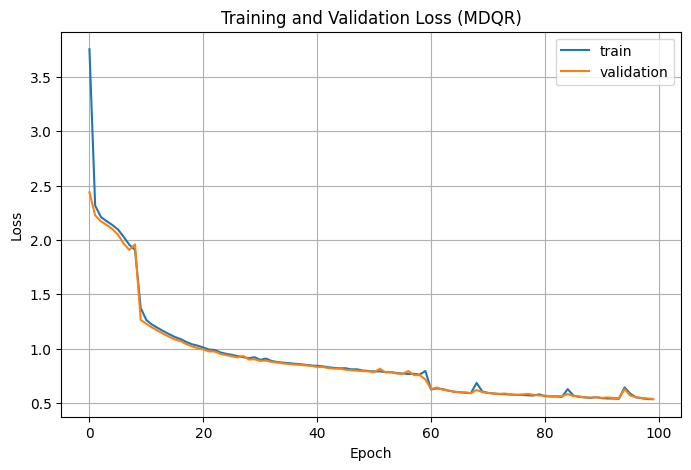

In [340]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (MDQR)")
plt.grid(True)
plt.legend()
plt.show()

In [341]:
# Rebuild the full state tensors

X_num_clean = X_num.apply(pd.to_numeric, errors="coerce").fillna(0.0)
X_cat_levels_clean = X_cat_levels.apply(pd.to_numeric, errors="coerce").fillna(3)

x_num_tensor = torch.tensor(
    X_num_clean.values.astype(np.float32),
    dtype=torch.float32
)

x_cat_levels_tensor = torch.tensor(
    X_cat_levels_clean.values.astype(np.int64),
    dtype=torch.long
)

x_cat_hour_tensor = torch.tensor(
    X_cat_hour.values.astype(np.int64),
    dtype=torch.long
)

model_intensity.eval()
with torch.no_grad():
    lam = model_intensity(
        x_num_tensor,
        x_cat_levels_tensor,
        x_cat_hour_tensor
    ).cpu().numpy()

In [342]:
#construction transition matrix 

EVENTS = [
    "cancel_ask",
    "cancel_bid",
    "limit_ask",
    "limit_bid",
    "trade_ask",
    "trade_bid"
]

def label_event(row):
    """
    Map historical event (type, lvl) -> one of the 6 labels:
    cancel_ask, cancel_bid, limit_ask, limit_bid, trade_ask, trade_bid

    Convention in your preprocessing:
    - L/C: lvl > 0 => ask, lvl < 0 => bid
    - M:   lvl < 0 => trade_ask, lvl > 0 => trade_bid
    """
    t = row["type"]
    lvl = row["lvl"]

    if t == "L":
        base = "limit"
        side = "ask" if lvl > 0 else "bid"

    elif t == "C":
        base = "cancel"
        side = "ask" if lvl > 0 else "bid"

    elif t == "M":
        base = "trade"
        side = "ask" if lvl < 0 else "bid"

    else:
        raise ValueError(f"Unknown event type: {t}")

    return f"{base}_{side}"

In [343]:
def row_normalize(counts):
    """
    Robust row normalization:
    if a row sum is zero, return zeros instead of NaN.
    """
    row_sums = counts.sum(axis=1)
    return counts.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

In [344]:
# 1) Real transition matrix

d = mdqr_seq.copy()

# Figure 9 focuses on best prices
d = d[d["lvl"].abs() == 1].copy()

d["event"] = d.apply(label_event, axis=1)
d["prev_event"] = d["event"].shift(1)

counts_real = pd.crosstab(d["prev_event"], d["event"])
counts_real = counts_real.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

real_mat = row_normalize(counts_real)

print("REAL TRANSITION MATRIX")
print(real_mat.round(3))


REAL TRANSITION MATRIX
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.362       0.095      0.337      0.178      0.017      0.011
cancel_bid       0.081       0.322      0.150      0.420      0.013      0.012
limit_ask        0.277       0.142      0.476      0.082      0.016      0.007
limit_bid        0.130       0.353      0.070      0.429      0.007      0.011
trade_ask        0.040       0.067      0.110      0.031      0.749      0.002
trade_bid        0.063       0.045      0.035      0.123      0.002      0.732


In [345]:
# 2) Simulated transition matrix from trained MDQR
# Decode event-level predictions, sample a simulated event sequence from the learned
# intensities, restrict to best-price events, and compute the simulated transition matrix

def decode_event_level(c, K=5):
    event = c // (2 * K)
    pos = c % (2 * K)

    if pos < K:
        lvl = -(pos + 1)
    else:
        lvl = pos - K + 1

    return event, lvl


def sample_from_prob(prob):
    rng = np.random.default_rng()
    return rng.choice(len(prob), p=prob)


def size_class_to_value(size_class, size_bins):
    """
    Convert predicted size class into a representative size value
    using the midpoint of the corresponding quantile interval.
    """
    interval = size_bins.cat.categories[size_class]
    return float((interval.left + interval.right) / 2.0)


def event_label_from_type_level(t, l):
    if t == "L":
        base = "limit"
        side = "ask" if l > 0 else "bid"
    elif t == "C":
        base = "cancel"
        side = "ask" if l > 0 else "bid"
    elif t == "M":
        base = "trade"
        side = "ask" if l < 0 else "bid"
    else:
        raise ValueError(f"Unknown event type: {t}")

    return f"{base}_{side}"

In [346]:
def apply_event_to_state(x_num_row, x_cat_levels_row, event_type_code, lvl, size_value, K=5):
    """
    Minimal recursive update of the simulated state.
    """
    x_num_new = x_num_row.copy()
    x_cat_new = x_cat_levels_row.copy()

    # queue column name
    q_col = f"Q_{lvl}"

    # because queues are stored as log(1+q), update in raw domain then transform back
    q_old_log = float(x_num_new[q_col])
    q_old = np.expm1(q_old_log)

    if event_type_code == 0:      # Limit order
        q_new = q_old + size_value
    elif event_type_code in [1, 2]:  # Cancel or Market
        q_new = max(0.0, q_old - size_value)
    else:
        q_new = q_old

    x_num_new[q_col] = np.log1p(q_new)

    # update last-event categorical feature at that level
    x_cat_new[f"e_{lvl}"] = int(event_type_code)

    return x_num_new, x_cat_new

In [352]:
def simulate_mdqr_market(
    model_intensity,
    model_size,
    X_num,
    X_cat_levels,
    X_cat_hour,
    X_prev_size,
    size_bins,
    n_steps=50000,
    K=5
):
    """
    Simulate a recursive market trajectory using both:
    - IntensityNet for event type/level
    - SizeNet for order size class

    Returns a DataFrame of simulated events.
    """
    model_intensity.eval()
    model_size.eval()

    # start from the first observed state
    x_num_state = X_num.iloc[0].copy()
    x_cat_levels_state = X_cat_levels.iloc[0].copy()
    x_cat_hour_state = int(X_cat_hour.iloc[0])
    x_prev_size_state = X_prev_size.iloc[0].copy()

    event_map = {0: "L", 1: "C", 2: "M"}

    sim_records = []

    for _ in range(n_steps):

        # prepare tensors
        x_num_tensor = torch.tensor(
            x_num_state.values.astype(np.float32)[None, :],
            dtype=torch.float32
        )

        x_cat_levels_tensor = torch.tensor(
            x_cat_levels_state.values.astype(np.int64)[None, :],
            dtype=torch.long
        )

        x_cat_hour_tensor = torch.tensor(
            np.array([x_cat_hour_state], dtype=np.int64),
            dtype=torch.long
        )

        # 1) intensity model -> sample event class
        with torch.no_grad():
            lam = model_intensity(
                x_num_tensor,
                x_cat_levels_tensor,
                x_cat_hour_tensor
            ).cpu().numpy()[0]

        lam = np.maximum(lam, 1e-12)
        lam_total = lam.sum()
        prob_event = lam / lam_total

        # simulate next inter-arrival time
        dtk_sim = np.random.exponential(scale=1.0 / lam_total)

        event_class = sample_from_prob(prob_event)
        event_type_code, lvl = decode_event_level(event_class, K=K)

        # 2) size model -> sample size class
        omega_cur_tensor = torch.tensor([event_type_code], dtype=torch.long)
        lvl_cur_tensor = torch.tensor([lvl], dtype=torch.long)

        x_prev_size_tensor = torch.tensor(x_prev_size_state.values.astype(np.float32)[None, :],
        dtype=torch.float32
        )

        with torch.no_grad():
            size_logits = model_size(
            x_num_tensor,
            x_cat_levels_tensor,
            x_cat_hour_tensor,
            omega_cur_tensor,
            lvl_cur_tensor,
            x_prev_size_tensor
    )

        size_prob = torch.softmax(size_logits, dim=1).cpu().numpy()[0]
        size_class = sample_from_prob(size_prob)
        size_value = size_class_to_value(size_class, size_bins)

        # 3) record event
        event_type = event_map[event_type_code]
        event_label = event_label_from_type_level(event_type, lvl)

        sim_records.append({
            "type": event_type,
            "lvl": lvl,
            "size": size_value,
            "event": event_label
        })

        # 4) update state using sampled event and sampled size
        x_num_state, x_cat_levels_state = apply_event_to_state(
            x_num_state,
            x_cat_levels_state,
            event_type_code,
            lvl,
            size_value,
            K=K
        )

        x_prev_size_state["omega_prev"] = float(event_type_code)
        x_prev_size_state["level_prev"] = float(lvl)
        x_prev_size_state["size_prev"] = float(size_value)
        x_prev_size_state["dtk"] = float(dtk_sim)

      

    return pd.DataFrame(sim_records)

In [353]:
# Run recursive MDQR market simulation 

sim = simulate_mdqr_market(
    model_intensity=model_intensity,
    model_size=model_size,
    X_num=X_num,
    X_cat_levels=X_cat_levels,
    X_cat_hour=X_cat_hour,
    X_prev_size=X_prev_size,
    size_bins=size_bins,
    n_steps=50000,
    K=5
)

print("SIMULATED EVENT TYPES")
print(sim["type"].value_counts())

print("\nSIMULATED BEST-PRICE EVENT TYPES")
print(sim[sim["lvl"].abs() == 1]["type"].value_counts())

sim_best = sim[sim["lvl"].abs() == 1].copy()
sim_best["prev_event"] = sim_best["event"].shift(1)

counts_sim = pd.crosstab(sim_best["prev_event"], sim_best["event"])
counts_sim = counts_sim.reindex(index=EVENTS, columns=EVENTS, fill_value=0)

sim_mat = row_normalize(counts_sim)

print("\nSIMULATED TRANSITION MATRIX (MDQR)")
print(sim_mat.round(3))

SIMULATED EVENT TYPES
type
C    24911
L    23248
M     1841
Name: count, dtype: int64

SIMULATED BEST-PRICE EVENT TYPES
type
C    14979
L    14741
M     1841
Name: count, dtype: int64

SIMULATED TRANSITION MATRIX (MDQR)
event       cancel_ask  cancel_bid  limit_ask  limit_bid  trade_ask  trade_bid
prev_event                                                                    
cancel_ask       0.405       0.076      0.313      0.136      0.069        0.0
cancel_bid       0.169       0.312      0.255      0.233      0.031        0.0
limit_ask        0.330       0.133      0.387      0.074      0.076        0.0
limit_bid        0.261       0.228      0.133      0.364      0.013        0.0
trade_ask        0.370       0.068      0.424      0.033      0.105        0.0
trade_bid        0.000       0.000      0.000      0.000      0.000        0.0


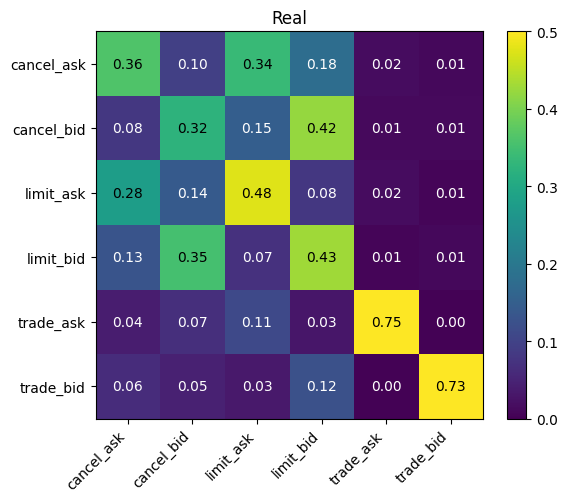

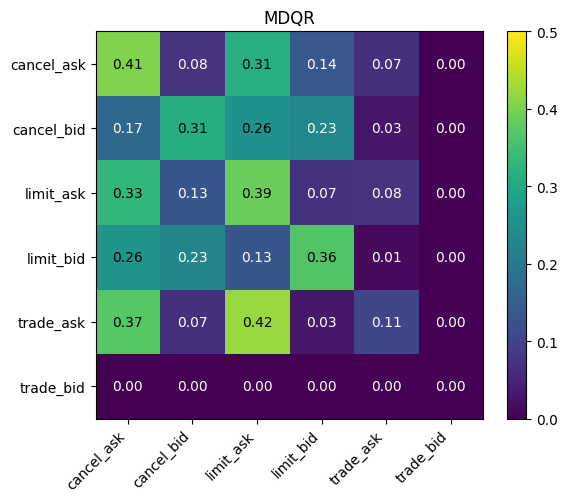

/var/folders/1f/ls1_y4xn1ljfvp6h5bvx9b580000gn/T/ipykernel_7861/3327935528.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


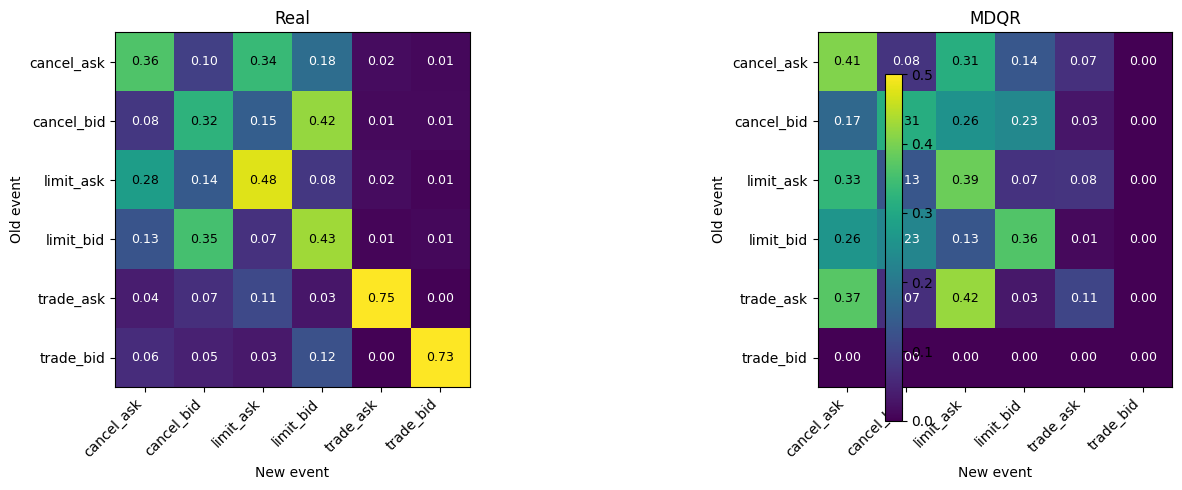

In [354]:
# 3) Plotting

def plot_transition(mat, title, vmin=0.0, vmax=0.5):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(mat.columns)))
    ax.set_yticks(range(len(mat.index)))

    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            color = "white" if val < 0.25 else "black"
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center", color=color, fontsize=10)

    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_transition_side_by_side(real_mat, sim_mat, vmin=0.0, vmax=0.5):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, mat, title in zip(
        axes,
        [real_mat, sim_mat],
        ["Real", "MDQR"]
    ):
        im = ax.imshow(mat.values, vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(mat.columns)))
        ax.set_yticks(range(len(mat.index)))

        ax.set_xticklabels(mat.columns, rotation=45, ha="right")
        ax.set_yticklabels(mat.index)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.iloc[i, j]
                color = "white" if val < 0.25 else "black"
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", color=color, fontsize=9)

        ax.set_title(title)
        ax.set_xlabel("New event")
        ax.set_ylabel("Old event")

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    plt.tight_layout()
    plt.show()


# individual plots
plot_transition(real_mat, "Real")
plot_transition(sim_mat, "MDQR")

# side-by-side plot 
plot_transition_side_by_side(real_mat, sim_mat)